In [105]:
import pandas as pd
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [106]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [108]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


visualizing the churn

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


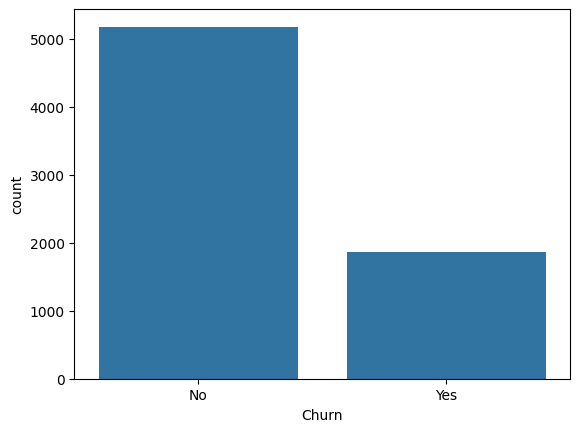

In [110]:
sns.countplot(
    x='Churn',
    data=df
)
plt.show()

Data is imbalanced model may predict No many times nearly 74% accuracy but it is useless

In [111]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [113]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [114]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [115]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

Exploring Important Features

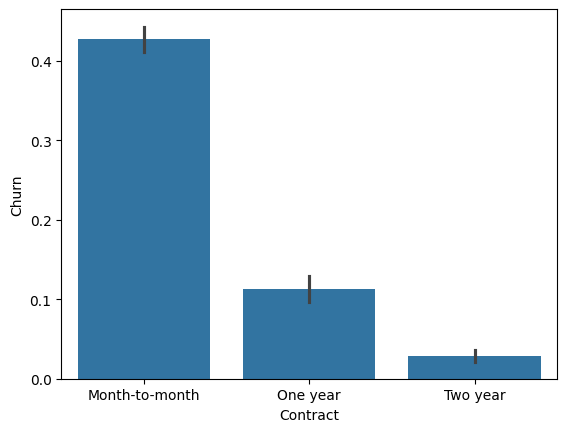

In [116]:
sns.barplot(
   x = 'Contract',
   y = (df['Churn']=='Yes').astype(int),
   data = df
)
plt.show()

mont-month customers churn more

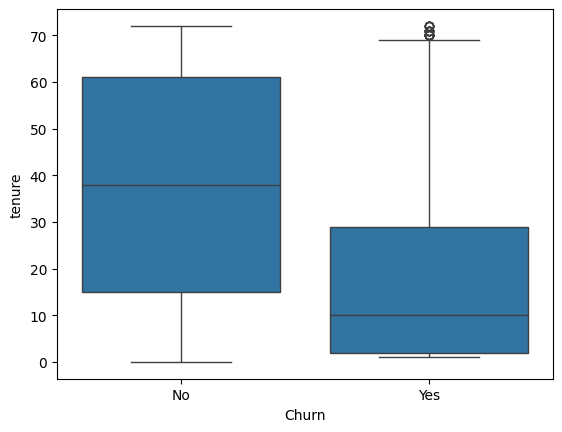

In [117]:
sns.boxplot(
    x='Churn',
    y='tenure',
    data = df
)
plt.show()

customers with shorter tenure leave more

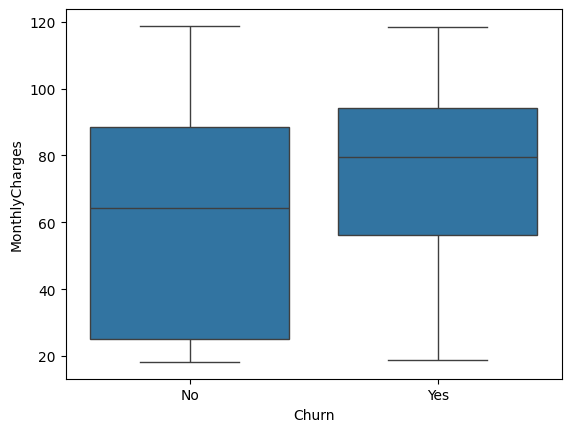

In [118]:
sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)
plt.show()

Higher monthly charges higher churn

Preprocessing

encode target

In [119]:
df['Churn'] = df['Churn'].map({
    'No':0,
    'Yes':1
})

In [120]:
df.drop(
    'customerID',
    axis = 1,
    inplace = True
)

One Hot encoder

In [121]:
df = pd.get_dummies(df,drop_first=True)

split features and target

In [122]:
x = df.drop('Churn',axis=1)
y = df['Churn']

Train Test split

In [123]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [124]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [125]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train_scaled,y_train)
prediction1 = lr.predict(x_test_scaled)

In [126]:
from sklearn.metrics import accuracy_score
lr_score = accuracy_score(prediction1,y_test)
print('Accuracy score of LogisticRegression : ',lr_score)

Accuracy score of LogisticRegression :  0.8197303051809794


In [127]:
from sklearn.metrics import classification_report
c_report_lr = classification_report(prediction1,y_test)
print(c_report_lr)

              precision    recall  f1-score   support

           0       0.90      0.86      0.88      1084
           1       0.60      0.68      0.64       325

    accuracy                           0.82      1409
   macro avg       0.75      0.77      0.76      1409
weighted avg       0.83      0.82      0.82      1409



In [128]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators = 200,
    random_state = 42
)
rf.fit(x_train,y_train)
prediction2 = rf.predict(x_test)
rf_score = accuracy_score(prediction2,y_test)
c_report_rf = classification_report(prediction2,y_test)
print(c_report_rf)

              precision    recall  f1-score   support

           0       0.91      0.82      0.87      1147
           1       0.46      0.66      0.54       262

    accuracy                           0.79      1409
   macro avg       0.69      0.74      0.70      1409
weighted avg       0.83      0.79      0.81      1409



In [129]:
print('Accuracy score of RandomForest : ',rf_score)

Accuracy score of RandomForest :  0.7934705464868701


In [142]:
rf2 = RandomForestClassifier(
    n_estimators=800,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)

In [143]:
rf2.fit(x_train,y_train)
prediction2 = rf2.predict(x_test)
print(accuracy_score(prediction2,y_test))

0.8019872249822569


In [156]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state = 42)
xgb.fit(x_train,y_train)
xgb_pred = xgb.predict(x_test)
print(classification_report(xgb_pred,y_test))

              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1113
           1       0.50      0.63      0.56       296

    accuracy                           0.79      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.81      0.79      0.80      1409



In [157]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': xgb.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
10,InternetService_Fiber optic,0.334715
25,Contract_Two year,0.182862
11,InternetService_No,0.152917
24,Contract_One year,0.076980
1,tenure,0.025021
7,PhoneService_Yes,0.023437
23,StreamingMovies_Yes,0.022337
28,PaymentMethod_Electronic check,0.015277
9,MultipleLines_Yes,0.013774
19,TechSupport_Yes,0.013629


Shap Analysis

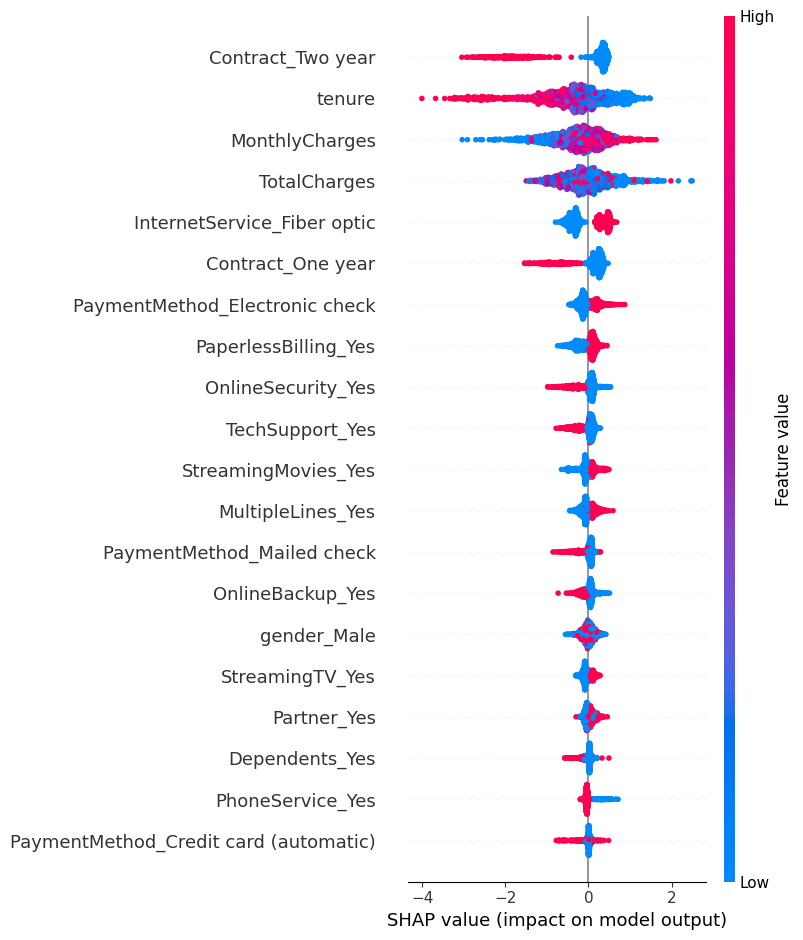

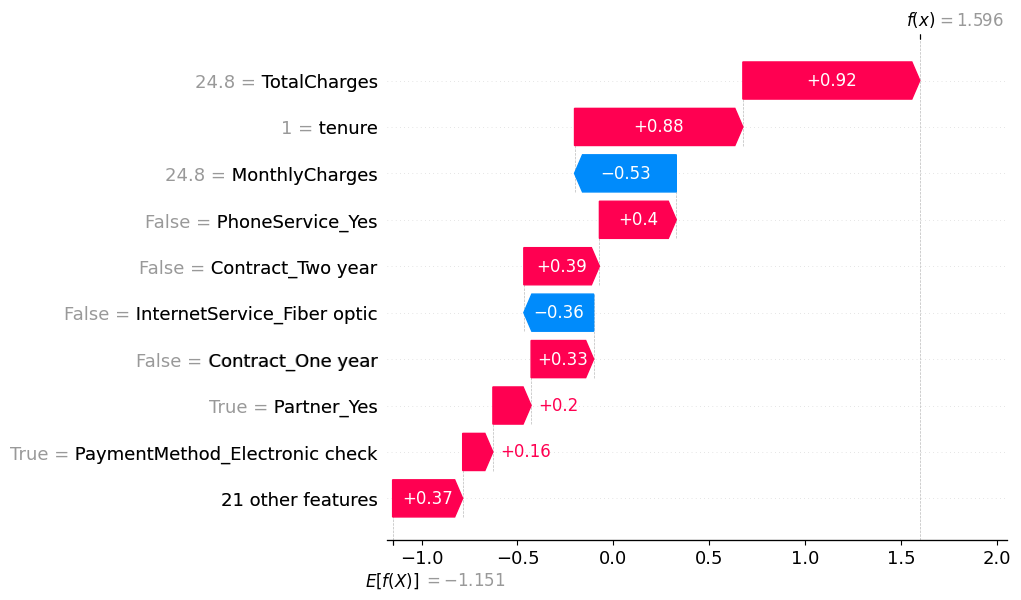

In [159]:
import shap
import matplotlib.pyplot as plt
explainer = shap.TreeExplainer(xgb)
shap_values = explainer(x_test)
shap.summary_plot(shap_values, x_test)
shap.plots.waterfall(shap_values[0])


shap shows that coustomers likely to churn becouse :

Month to month contract

High monthly charges

short tenure

Electonic payment

In [160]:
! pip freeze > requirements.txt